 Выполнил: Глушко Игорь М80-312Б-23

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [35]:

df = pd.read_csv("datasets/train.csv")
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


In [36]:
test = pd.read_csv("datasets/test.csv")

## EDA

In [4]:
print("\nСтруктура датасета:")
print(df.info())



Структура датасета:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToInco

In [5]:
print("\nПроверка на пропуски в данных:")
df.isnull().sum()


Проверка на пропуски в данных:


ApplicationDate                530
Age                            530
AnnualIncome                   530
CreditScore                   1031
LoanAmount                    1031
LoanDuration                   530
MaritalStatus                  530
NumberOfDependents             530
HomeOwnershipStatus            530
MonthlyDebtPayments           1031
CreditCardUtilizationRate      530
NumberOfOpenCreditLines        530
NumberOfCreditInquiries        530
DebtToIncomeRatio              530
BankruptcyHistory             1031
LoanPurpose                   1031
PreviousLoanDefaults           530
PaymentHistory                 530
LengthOfCreditHistory          530
SavingsAccountBalance          530
CheckingAccountBalance        1031
TotalAssets                   1031
TotalLiabilities               530
MonthlyIncome                  530
UtilityBillsPaymentHistory     530
JobTenure                      530
EmploymentStatus               530
EducationLevel                 530
Experience          

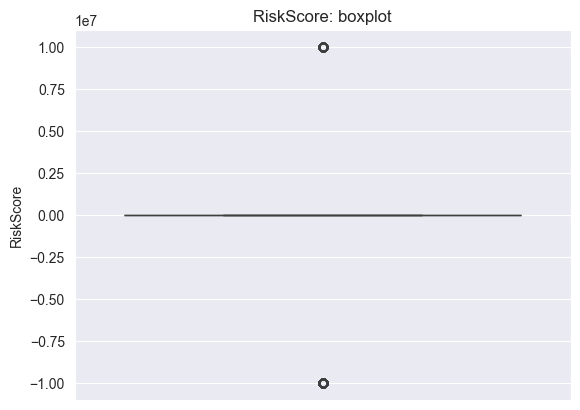

In [6]:
fig = sns.boxplot(df["RiskScore"])
fig.set_title("RiskScore: boxplot")
plt.show()


    Можно заметить 2 существенных выброса, которые нужно отбросить

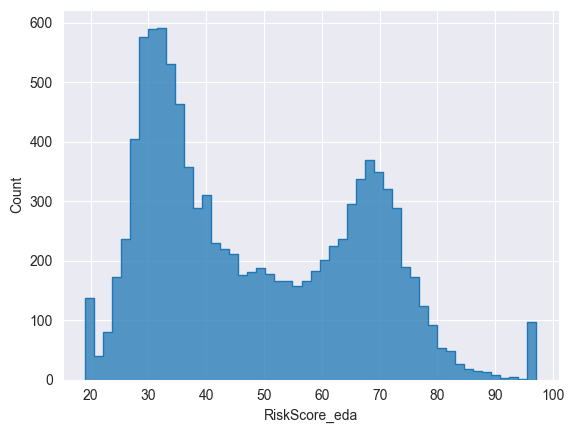

In [7]:
eda = df.copy()

y = pd.to_numeric(eda["RiskScore"], errors="coerce").replace([np.inf, -np.inf], np.nan)
low, high = y.quantile(
    [0.012, 0.991]
)
eda["RiskScore_eda"] = y.clip(lower=low, upper=high)

sns.histplot(eda["RiskScore_eda"].dropna(), bins=50, element="step")
plt.show()

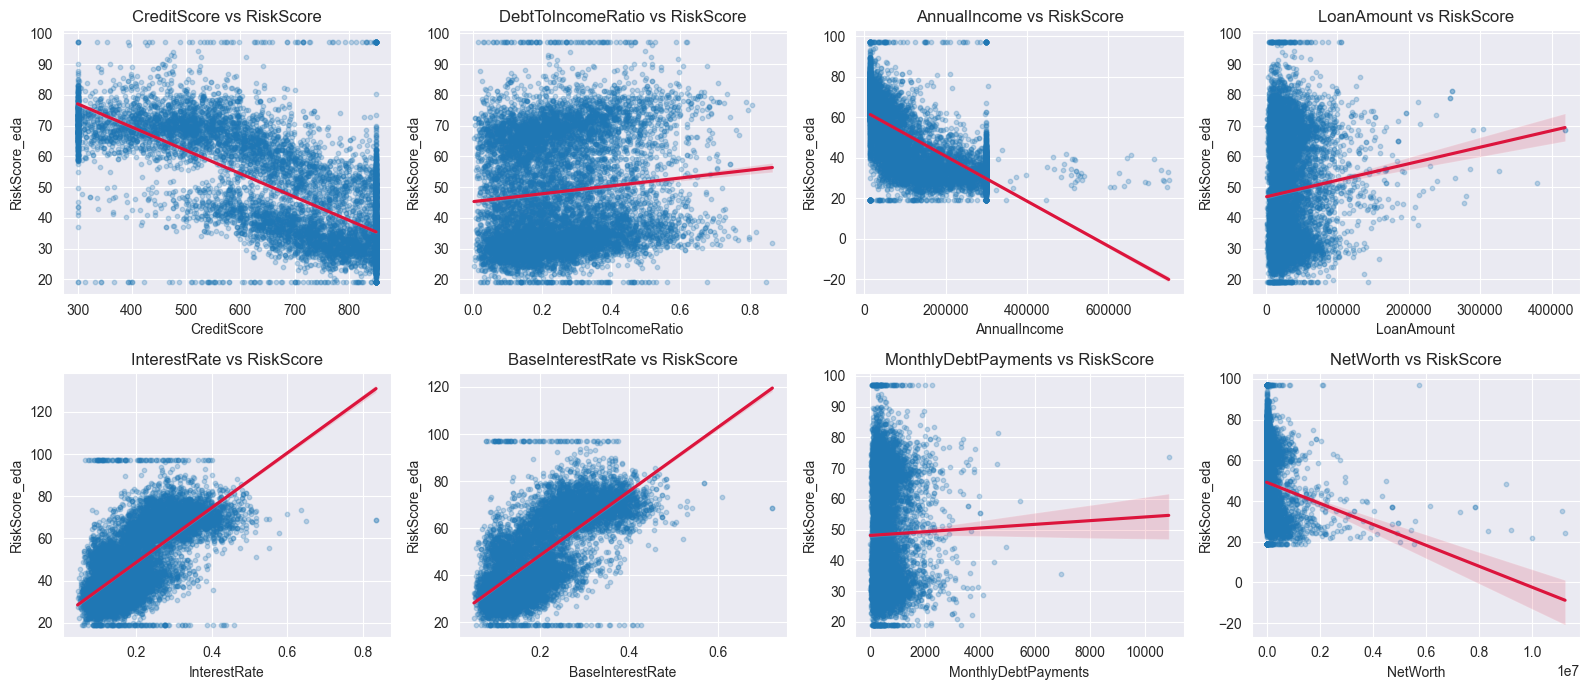

In [8]:
num_cols = [
    "CreditScore",
    "DebtToIncomeRatio",
    "AnnualIncome",
    "LoanAmount",
    "InterestRate",
    "BaseInterestRate",
    "MonthlyDebtPayments",
    "NetWorth",
]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    x = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    sns.regplot(
        x=x,
        y=eda["RiskScore_eda"],
        scatter_kws={"alpha": 0.25, "s": 10},
        line_kws={"color": "crimson"},
        ax=ax,
    )
    ax.set_title(f"{col} vs RiskScore")
plt.tight_layout()
plt.show()


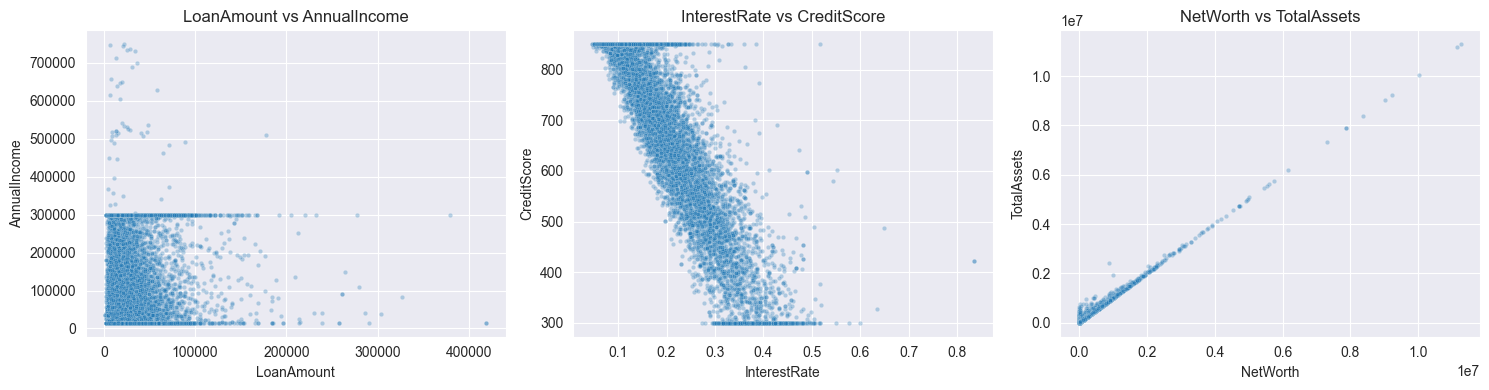

In [10]:
pairs = [
    ("LoanAmount", "AnnualIncome"),
    ("InterestRate", "CreditScore"),
    ("NetWorth", "TotalAssets"),
]
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
for ax, (a, b) in zip(axes, pairs):
    xa = pd.to_numeric(df[a], errors="coerce")
    xb = pd.to_numeric(df[b], errors="coerce")
    sns.scatterplot(x=xa, y=xb, s=10, alpha=0.3, ax=ax)
    ax.set_title(f"{a} vs {b}")
plt.tight_layout()
plt.show()

<Axes: >

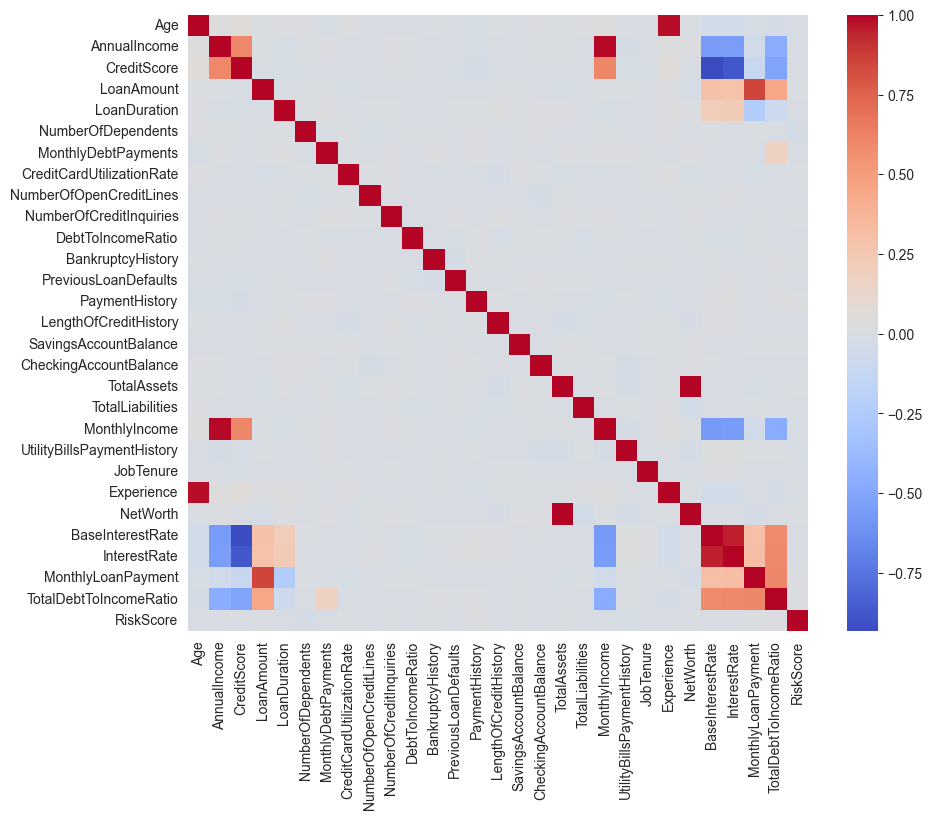

In [11]:
num = df.select_dtypes("number").replace([np.inf, -np.inf], np.nan)
num_f = num.apply(lambda s: s.fillna(s.median()))
corr = num_f.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm")

In [12]:
print(df["RiskScore"].describe())
print(df["RiskScore"].value_counts().head(10))

count    1.048700e+04
mean    -2.569878e+04
std      1.431675e+06
min     -9.999999e+06
25%      3.256475e+01
50%      4.411876e+01
75%      6.535690e+01
max      1.000000e+07
Name: RiskScore, dtype: float64
RiskScore
-9.999999e+06    121
 1.000000e+07     94
 6.554056e+01      3
 6.785041e+01      3
 3.513328e+01      3
 6.495533e+01      3
 3.704447e+01      3
 7.801113e+01      3
 5.040845e+01      3
 6.485634e+01      3
Name: count, dtype: int64


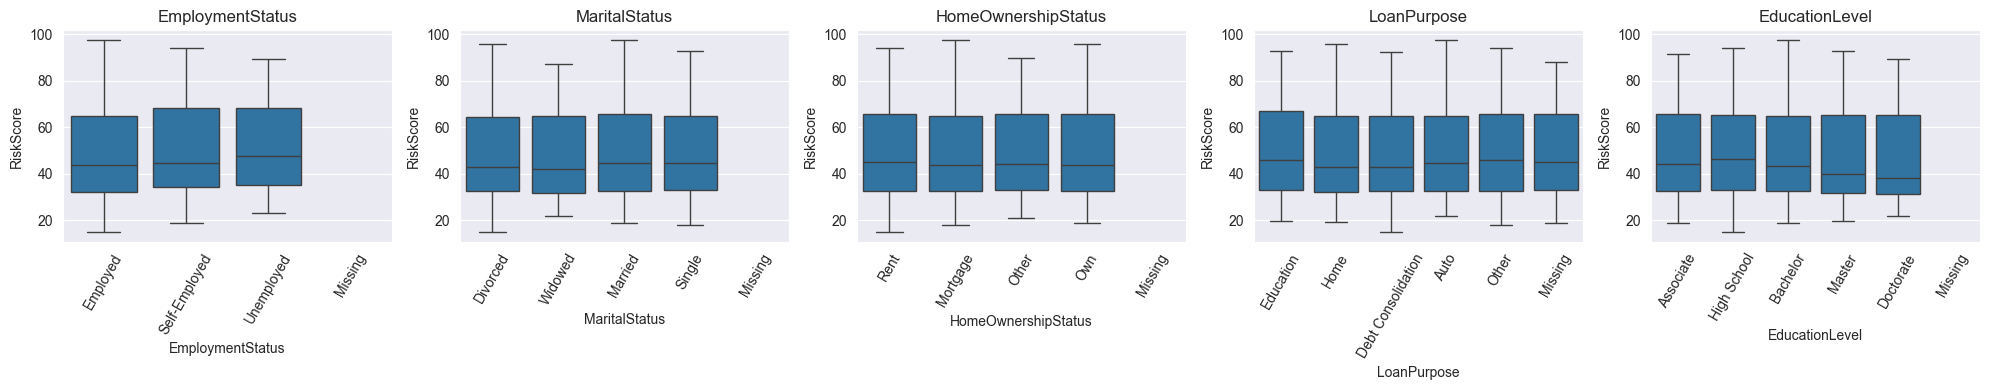

In [9]:
cat_cols = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "EducationLevel",
]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(4 * len(cat_cols), 4))
for ax, col in zip(axes, cat_cols):
    s = df[col].fillna("Missing")
    sns.boxplot(x=s, y=y, showfliers=False, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

# Скейлеры

In [37]:
from sklearn.preprocessing import StandardScaler as SkStandardScaler
from sklearn.preprocessing import MinMaxScaler as SkMinMaxScaler

scaler = SkStandardScaler()


class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0, ddof=0)
        self.scale_[self.scale_ == 0] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class MinMaxScaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        denom = self.max_ - self.min_
        denom[denom == 0] = 1.0
        return (X - self.min_) / denom

    def fit_transform(self, X):
        return self.fit(X).transform(X)


np.random.seed(42)
X_random = np.column_stack([
    np.random.rand(100) * 1000,
    np.random.rand(100) * 4 - 5,
    np.random.normal(10, 2, 100)
])

print("\n--- Сравнение StandardScaler ---")

my_std = StandardScaler()
X_my_std = my_std.fit_transform(X_random)

sk_std = SkStandardScaler()
X_sk_std = sk_std.fit_transform(X_random)

diff_std = np.max(np.abs(X_my_std - X_sk_std))
print(f"Мой результат (первая строка): {X_my_std[0]}")
print(f"Sklearn результат (первая строка): {X_sk_std[0]}")
print(f"Максимальная разница между матрицами: {diff_std:.10f}")

print("\n--- Сравнение MinMaxScaler ---")

my_mms = MinMaxScaler()
X_my_mms = my_mms.fit_transform(X_random)

sk_mms = SkMinMaxScaler()
X_sk_mms = sk_mms.fit_transform(X_random)

diff_mms = np.max(np.abs(X_my_mms - X_sk_mms))
print(f"Мой результат (первая строка): {X_my_mms[0]}")
print(f"Sklearn результат (первая строка): {X_sk_mms[0]}")
print(f"Максимальная разница между матрицами: {diff_mms:.10f}")



--- Сравнение StandardScaler ---
Мой результат (первая строка): [-0.32311215 -1.59922959 -0.78752449]
Sklearn результат (первая строка): [-0.32311215 -1.59922959 -0.78752449]
Максимальная разница между матрицами: 0.0000000000

--- Сравнение MinMaxScaler ---
Мой результат (первая строка): [0.3760253  0.02500981 0.22884428]
Sklearn результат (первая строка): [0.3760253  0.02500981 0.22884428]
Максимальная разница между матрицами: 0.0000000000


# Модель

In [14]:
class MyLinearRegression:
    def __init__(
            self,
            lr=0.01,
            n_iters=1000,
            solver="normal",  # "normal", "gd", "sgd"
            batch_size=32,
            random_state=42,
            reg_type="none",  # "none", "l1", "l2", "elastic", "lp"
            lambda_l1=0.0,
            lambda_l2=0.0,
            lambda_lp=0.0,
            p=1.0,
    ):
        self.lr = lr
        self.n_iters = n_iters
        self.solver = solver
        self.batch_size = batch_size
        self.random_state = random_state

        self.reg_type = reg_type
        self.lambda_l1 = lambda_l1
        self.lambda_l2 = lambda_l2
        self.lambda_lp = lambda_lp
        self.p = p

        self.w = None

    def _add_bias(self, X):
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]
        return np.hstack([np.ones((n_samples, 1)), X])

    def _reg_gradient(self, w):
        grad = np.zeros_like(w)

        w_no_bias = w.copy()
        w_no_bias[0] = 0.0

        if self.reg_type == "l2":
            # L2: lambda * ||w||_2^2 -> grad = 2 * lambda * w
            grad += 2.0 * self.lambda_l2 * w_no_bias

        elif self.reg_type == "l1":
            # L1: lambda * ||w||_1 -> grad = lambda * sign(w)
            grad += self.lambda_l1 * np.sign(w_no_bias)

        elif self.reg_type == "elastic":
            # L1 + L2 (Elastic Net)
            grad += self.lambda_l1 * np.sign(w_no_bias)
            grad += 2.0 * self.lambda_l2 * w_no_bias

        elif self.reg_type == "lp":
            # Lp: lambda * ||w||_p^p
            # ||w||_p^p = sum |w_i|^p
            # d/dw_i = lambda * p * |w_i|^(p-1) * sign(w_i)
            abs_w = np.abs(w_no_bias) + 1e-12
            grad += (
                    self.lambda_lp * self.p * (abs_w ** (self.p - 1.0)) * np.sign(w_no_bias)
            )

        return grad

    def fit(self, X, y):
        Xb = self._add_bias(X)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = Xb.shape

        if self.solver == "normal":
            XtX = Xb.T @ Xb
            Xty = Xb.T @ y

            if self.reg_type in ["none", "l1", "elastic", "lp"]:
                # без аналитики для L1/Lp/elastic
                self.w = np.linalg.pinv(XtX) @ Xty

            elif self.reg_type == "l2":
                # Ridge: (X^T X + lambda * I)^{-1} X^T y
                R = np.eye(n_features)
                R[0, 0] = 0.0
                A = XtX + self.lambda_l2 * R
                self.w = np.linalg.pinv(A) @ Xty

        elif self.solver == "gd":
            rng = np.random.default_rng(self.random_state)
            self.w = rng.normal(0, 0.01, size=n_features)

            for _ in range(self.n_iters):
                y_pred = Xb @ self.w
                grad_mse = (2.0 / n_samples) * (Xb.T @ (y_pred - y))
                grad_reg = self._reg_gradient(self.w)
                grad = grad_mse + grad_reg
                self.w -= self.lr * grad

        elif self.solver == "sgd":
            rng = np.random.default_rng(self.random_state)
            self.w = rng.normal(0, 0.01, size=n_features)

            for _ in range(self.n_iters):
                indices = rng.permutation(n_samples)
                Xb_sh = Xb[indices]
                y_sh = y[indices]

                for start in range(0, n_samples, self.batch_size):
                    end = start + self.batch_size
                    X_batch = Xb_sh[start:end]
                    y_batch = y_sh[start:end]
                    if X_batch.shape[0] == 0:
                        continue

                    y_pred = X_batch @ self.w
                    grad_mse = (2.0 / X_batch.shape[0]) * (
                            X_batch.T @ (y_pred - y_batch)
                    )
                    grad_reg = self._reg_gradient(self.w)
                    grad = grad_mse + grad_reg
                    self.w -= self.lr * grad
        else:
            raise ValueError("Unknown solver")

    def predict(self, X):
        Xb = self._add_bias(X)
        return Xb @ self.w

In [15]:
def norm(s):
    return (s - s.min()) / (s.max() - s.min())


def make_features(df_in):
    df = df_in.copy()

    # Даты
    df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
    min_date = pd.Timestamp("1970-01-01")
    df["AppYear"] = df["ApplicationDate"].dt.year
    df["AppMonth"] = df["ApplicationDate"].dt.month
    df["AppDays"] = (df["ApplicationDate"] - min_date).dt.days

    fill_cols = ["AnnualIncome", "TotalAssets", "TotalLiabilities", "NetWorth"]
    for c in fill_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())

    # Отношения
    df["Income_per_person"] = df["AnnualIncome"] / (df["NumberOfDependents"] + 1)
    df["Liabilities_to_Income"] = df["TotalLiabilities"] / (df["AnnualIncome"] + 10)
    df["Assets_to_Income"] = df["TotalAssets"] / (df["AnnualIncome"] + 10)
    df["Savings_to_Income"] = df["SavingsAccountBalance"] / (df["AnnualIncome"] + 10)

    for col in [
        "AnnualIncome",
        "LoanAmount",
        "TotalAssets",
        "TotalLiabilities",
        "NetWorth",
    ]:
        if col in df.columns:
            min_val = df[col].min()
            shift = abs(min_val) + 1.0 if min_val < 0 else 1.0
            df[f"log_{col}"] = np.log(df[col] + shift)

    # Взаимодействия
    df["Interest_Spread"] = df["InterestRate"] - df["BaseInterestRate"]
    df["CreditScore_sq"] = df["CreditScore"] ** 2

    df["Total_Payment_to_Income"] = (
                                            df["MonthlyDebtPayments"] + df["MonthlyLoanPayment"]
                                    ) / (df["MonthlyIncome"] + 10)
    df["Asset_Coverage"] = df["TotalAssets"] / (df["TotalLiabilities"] + 10)
    df["Negative_NetWorth"] = (df["NetWorth"] < 0).astype(int)
    df['Age_Bin'] = pd.qcut(df['Age'], q=5, labels=False, duplicates='drop')
    df['Income_Bin'] = pd.qcut(df['AnnualIncome'], q=5, labels=False, duplicates='drop')

    # "Плохой" клиент имеет:
    # CreditScore = 0 (минимум)
    # AnnualIncome = 0 (минимум)
    # DebtToIncomeRatio = 1 (максимум)

    # Считаем Евклидово расстояние до точки (Score=0, Income=0, Debt=1)
    # Чем меньше расстояние, тем хуже клиент

    df['Dist_to_Bad'] = np.sqrt(
        norm(df['CreditScore']) ** 2 +
        norm(df['AnnualIncome']) ** 2 +
        (1 - norm(df['DebtToIncomeRatio'])) ** 2
    )

    #  расстояние до Идеального клиента (1, 1, 0)
    df['Dist_to_Good'] = np.sqrt(
        (1 - norm(df['CreditScore'])) ** 2 +
        (1 - norm(df['AnnualIncome'])) ** 2 +
        norm(df['DebtToIncomeRatio']) ** 2
    )

    try:
        df['CreditScore_Bin'] = pd.qcut(df['CreditScore'], q=10, labels=False, duplicates='drop')
    except:
        pass

    # Биннинг Суммы Кредита
    df['LoanAmount_Bin'] = pd.qcut(df['LoanAmount'], q=10, labels=False, duplicates='drop')

    # Биннинг Долговой Нагрузки
    df['DTI_Bin'] = pd.qcut(df['DebtToIncomeRatio'], q=10, labels=False, duplicates='drop')

    # Длительность как категория
    df['Duration_Cat'] = df['LoanDuration'].astype(int).astype(str)

    try:
        df['NetWorth_Bin'] = pd.qcut(df['NetWorth'], q=5, labels=False, duplicates='drop')
    except:
        pass

    return df

In [16]:
from sklearn.feature_selection import VarianceThreshold

low_q = df["RiskScore"].quantile(0.012)
high_q = df["RiskScore"].quantile(0.991)
df_clean = df[(df["RiskScore"] >= low_q) & (df["RiskScore"] <= high_q)].reset_index(
    drop=True
)

print("Генерация признаков...")
df_train_fe = make_features(df_clean)
df_test_fe = make_features(test)

te_cols = ["EducationLevel", "EmploymentStatus", "HomeOwnershipStatus", "LoanPurpose", "Age_Bin", "Income_Bin",
           "CreditScore_Bin", "LoanAmount_Bin", "DTI_Bin", "Duration_Cat", "NetWorth_Bin"]
global_mean = df_clean["RiskScore"].median()

print("Добавляем Target Encoding...")
for col in te_cols:
    means = df_train_fe.groupby(col)["RiskScore"].median()

    df_train_fe[f"{col}_TE"] = df_train_fe[col].map(means).fillna(global_mean)
    df_test_fe[f"{col}_TE"] = df_test_fe[col].map(means).fillna(global_mean)

cat_cols = [
    "MaritalStatus",
    "EmploymentStatus",
    "EducationLevel",
    "LoanPurpose",
    "HomeOwnershipStatus",
    "Age_Bin",
    "Income_Bin",
    "NetWorth_Bin"

]
exclude_cols = ["RiskScore", "Id", "ID", "ApplicationDate"] + cat_cols
num_cols = [
    c
    for c in df_train_fe.select_dtypes(include=["number"]).columns
    if c not in exclude_cols
]

print("Кодирование категорий...")
X_train_cat = pd.get_dummies(df_train_fe[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(df_test_fe[cat_cols], drop_first=True)

X_train_cat, X_test_cat = X_train_cat.align(
    X_test_cat, join="left", axis=1, fill_value=0
)

X_train_num = df_train_fe[num_cols].fillna(0).values
X_test_num = df_test_fe[num_cols].fillna(0).values
y = df_train_fe["RiskScore"].values

var_filter = VarianceThreshold(threshold=0)
X_train_num = var_filter.fit_transform(X_train_num)
X_test_num = var_filter.transform(X_test_num)

print(f"Признаков после удаления констант: {X_train_num.shape[1]}")

Генерация признаков...
Добавляем Target Encoding...
Кодирование категорий...
Признаков после удаления констант: 60


In [17]:
from sklearn.preprocessing import PolynomialFeatures

print("Создание полиномов...")
# топ-20 признаков по корреляции Пирсона
correlations = []
for i in range(X_train_num.shape[1]):
    corr = np.corrcoef(X_train_num[:, i], y)[0, 1]
    if np.isnan(corr):
        corr = 0
    correlations.append(abs(corr))

# Degree 2 (Топ-20)
top_20_idx = np.argsort(correlations)[-20:]
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_p2 = poly2.fit_transform(X_train_num[:, top_20_idx])[:, 20:]
X_test_p2 = poly2.transform(X_test_num[:, top_20_idx])[:, 20:]

# Degree 3 (Топ-5)
top_5_idx = np.argsort(correlations)[-5:]
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_p3_raw = poly3.fit_transform(X_train_num[:, top_5_idx])
X_test_p3_raw = poly3.transform(X_test_num[:, top_5_idx])

n_deg2 = PolynomialFeatures(degree=2).fit(X_train_num[:, top_5_idx]).n_output_features_ - 1
X_train_p3 = X_train_p3_raw[:, n_deg2:]
X_test_p3 = X_test_p3_raw[:, n_deg2:]

X_full_train = np.hstack([X_train_num, X_train_p2, X_train_p3, X_train_cat.values])
X_full_test = np.hstack([X_test_num, X_test_p2, X_test_p3, X_test_cat.values])

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_full_train)
X_scaled_test = scaler.transform(X_full_test)

print(f"Всего признаков: {X_scaled_train.shape[1]}")



Создание полиномов...
Всего признаков: 324


In [18]:
print("Отбор признаков...")

sel_model = MyLinearRegression(solver="normal", reg_type="l2", lambda_l2=10.0)
sel_model.fit(X_scaled_train, y)
weights = np.abs(sel_model.w[1:])

top_idx = np.argsort(weights)[-285:]
X_tr = X_scaled_train[:, top_idx]
X_te = X_scaled_test[:, top_idx]

print(f"Признаков: {X_tr.shape[1]}")

Отбор признаков...
Признаков: 285


In [19]:
scaler_z_custom = StandardScaler()
X_z = scaler_z_custom.fit_transform(X_full_train)

scaler_mm_custom = MinMaxScaler()
X_mm = scaler_mm_custom.fit_transform(X_full_train)

from sklearn.preprocessing import StandardScaler as SkStandardScaler, MinMaxScaler as SkMinMaxScaler

scaler_z_skl = SkStandardScaler()
scaler_mm_skl = SkMinMaxScaler()

X_z_skl = scaler_z_skl.fit_transform(X_full_train)
X_mm_skl = scaler_mm_skl.fit_transform(X_full_train)

print("z-score diff:", np.max(np.abs(X_z - X_z_skl)))
print("min-max diff:", np.max(np.abs(X_mm - X_mm_skl)))

z-score diff: 0.0
min-max diff: 6.439293542825908e-15


метрики

In [20]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)


def myMSE(y_ans: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sum((y_ans - y_pred) ** 2) / len(y_ans)


def myMAE(y_ans: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sum(np.abs(y_ans - y_pred)) / len(y_ans)


def myMAPE(y_ans: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sum(abs((y_ans - y_pred) / y_ans)) / len(y_ans)


def myR2(y_ans: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_ans - y_pred) ** 2)
    ss_tot = np.sum((y_ans - y_ans.mean()) ** 2)
    return 1 - ss_res / ss_tot


rng = np.random.default_rng(0)
yt = rng.normal(size=100)
yp = yt + rng.normal(scale=0.1, size=100)

print("MSE:", myMSE(yt, yp), mean_squared_error(yt, yp))
print("MAE:", myMAE(yt, yp), mean_absolute_error(yt, yp))
print("R2 :", myR2(yt, yp), r2_score(yt, yp))
print("MAPE: ", myMAPE(yt, yp), mean_absolute_percentage_error(yt, yp))

MSE: 0.009159238635047957 0.009159238635047957
MAE: 0.07663391819957938 0.07663391819957938
R2 : 0.990105554858397 0.990105554858397
MAPE:  0.41478223097734856 0.41478223097734856


In [21]:
from sklearn.model_selection import KFold, cross_val_score, LeaveOneOut
from sklearn.linear_model import LinearRegression


def k_fold_cv(model_class, X, y, k=5, random_state=42, **model_kwargs):
    n = X.shape[0]
    indices = np.arange(n)
    rng = np.random.default_rng(random_state)
    rng.shuffle(indices)

    fold_sizes = np.full(k, n // k)
    fold_sizes[: n % k] += 1

    current = 0
    scores = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_idx = indices[start:stop]
        train_idx = np.concatenate([indices[:start], indices[stop:]])

        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        model = model_class(**model_kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        scores.append(myMSE(y_val, y_pred))
        current = stop
    return np.array(scores)


def loo_cv(model_class, X, y, **model_kwargs):
    n = X.shape[0]
    scores = []
    for i in range(n):
        train_mask = np.ones(n, dtype=bool)
        train_mask[i] = False

        X_train, y_train = X[train_mask], y[train_mask]
        X_val, y_val = X[~train_mask], y[~train_mask]

        model = model_class(**model_kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        scores.append(myMSE(y_val, y_pred))
    return np.array(scores)


print("=== Демонстрация Кросс-валидации на случайных данных ===")

np.random.seed(42)
X_cv_test = np.random.rand(50, 2)
true_weights = np.array([3.0, -2.0])
y_cv_test = X_cv_test @ true_weights + np.random.normal(0, 0.1, 50)

print("\n--- Сравнение K-Fold (k=5) ---")

my_cv_results = k_fold_cv(
    MyLinearRegression,
    X_cv_test,
    y_cv_test,
    k=5,
    solver='normal'
)

kf = KFold(n_splits=5, shuffle=False)
sk_cv_results = cross_val_score(
    LinearRegression(),
    X_cv_test,
    y_cv_test,
    cv=kf,
    scoring='neg_mean_squared_error'
)
sk_cv_results = -sk_cv_results

print(f"Мои MSE по фолдам (MyLinearRegression): {my_cv_results}")
print(f"Sklearn MSE по фолдам (Sklearn LinearRegression): {sk_cv_results}")
print(f"Средний MSE (My): {my_cv_results.mean():.6f}")
print(f"Средний MSE (Sklearn): {sk_cv_results.mean():.6f}")
print(f"Разница средних: {abs(my_cv_results.mean() - sk_cv_results.mean()):.10f}")

print("\n--- Сравнение Leave-One-Out ---")

my_loo_results = loo_cv(
    MyLinearRegression,
    X_cv_test,
    y_cv_test,
    solver='normal'
)

loo = LeaveOneOut()
sk_loo_results = cross_val_score(
    LinearRegression(),
    X_cv_test,
    y_cv_test,
    cv=loo,
    scoring='neg_mean_squared_error'
)
sk_loo_results = -sk_loo_results

print(f"Средний MSE (My LOO): {my_loo_results.mean():.6f}")
print(f"Средний MSE (Sklearn LOO): {sk_loo_results.mean():.6f}")


=== Демонстрация Кросс-валидации на случайных данных ===

--- Сравнение K-Fold (k=5) ---
Мои MSE по фолдам (MyLinearRegression): [0.01281551 0.01356501 0.00748737 0.01286581 0.00206581]
Sklearn MSE по фолдам (Sklearn LinearRegression): [0.00726575 0.00469531 0.00502085 0.01295423 0.01341147]
Средний MSE (My): 0.009760
Средний MSE (Sklearn): 0.008670
Разница средних: 0.0010903834

--- Сравнение Leave-One-Out ---
Средний MSE (My LOO): 0.009199
Средний MSE (Sklearn LOO): 0.009199


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y, test_size=0.2, random_state=42
)

my_model = MyLinearRegression(solver="normal", reg_type="none")
my_model.fit(X_train, y_train)
y_pred_my = my_model.predict(X_val)

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_val)

print("=== MyLinearRegression (normal) ===")
print(f"MSE : {myMSE(y_val, y_pred_my):.4f}")
print(f"MAE : {myMAE(y_val, y_pred_my):.4f}")
print(f"R2  : {myR2(y_val, y_pred_my):.4f}")
print(f"MAPE: {myMAE(y_val, y_pred_my):.4f}")

print("\n=== sklearn.LinearRegression ===")
print(f"MSE : {mean_squared_error(y_val, y_pred_sk):.4f}")
print(f"MAE : {mean_absolute_error(y_val, y_pred_sk):.4f}")
print(f"R2  : {r2_score(y_val, y_pred_sk):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_val, y_pred_sk):.4f}")

=== MyLinearRegression (normal) ===
MSE : 28.1701
MAE : 3.8939
R2  : 0.9074
MAPE: 3.8939

=== sklearn.LinearRegression ===
MSE : 28.1528
MAE : 3.8935
R2  : 0.9074
MAPE: 0.0899


In [24]:
for solver in ["normal", "gd", "sgd"]:
    scores = k_fold_cv(
        MyLinearRegression,
        X_tr,
        y,
        k=5,
        solver=solver,
        lr=1e-3,
        n_iters=3000,
        batch_size=32,
    )
    print(solver, "k-fold MSE:", scores.mean(), "+/-", scores.std())

normal k-fold MSE: 27.85649891213953 +/- 2.8195252164800566
gd k-fold MSE: 30.455196233367577 +/- 1.5095567216575638
sgd k-fold MSE: 27.240518633702152 +/- 1.310465866805277


In [25]:
lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
iters = [300, 1000, 3000]
mse_min = 1e9
best_lr_for_gd, best_iters_for_gd = 0, 0
for lr in lrs:
    for n_it in iters:
        scores = k_fold_cv(
            MyLinearRegression,
            X_z,
            y,
            k=5,
            solver="gd",
            lr=lr,
            n_iters=n_it,
        )
        mse = scores.mean()
        print(
            f"GD lr={lr}, n_iters={n_it} -> "
            f"MSE={mse:.3f} +/- {scores.std():.3f}"
        )
        if mse < mse_min:
            best_lr_for_gd, best_iters_for_gd = lr, n_it
# best_lr_for_gd = 0.001
# best_iters_for_gd = 3000
print(best_lr_for_gd, best_iters_for_gd)

GD lr=1e-05, n_iters=300 -> MSE=2447.942 +/- 13.083
GD lr=1e-05, n_iters=1000 -> MSE=2321.434 +/- 7.305
GD lr=1e-05, n_iters=3000 -> MSE=2135.814 +/- 8.032
GD lr=3e-05, n_iters=300 -> MSE=2332.780 +/- 7.241
GD lr=3e-05, n_iters=1000 -> MSE=2135.808 +/- 8.033
GD lr=3e-05, n_iters=3000 -> MSE=1685.065 +/- 8.617
GD lr=0.0001, n_iters=300 -> MSE=2135.785 +/- 8.034
GD lr=0.0001, n_iters=1000 -> MSE=1620.449 +/- 8.641
GD lr=0.0001, n_iters=3000 -> MSE=750.199 +/- 7.611
GD lr=0.0003, n_iters=300 -> MSE=1684.903 +/- 8.620
GD lr=0.0003, n_iters=1000 -> MSE=750.030 +/- 7.611
GD lr=0.0003, n_iters=3000 -> MSE=98.765 +/- 3.664
GD lr=0.001, n_iters=300 -> MSE=749.437 +/- 7.610
GD lr=0.001, n_iters=1000 -> MSE=76.755 +/- 3.264
GD lr=0.001, n_iters=3000 -> MSE=30.454 +/- 1.568
0.001 3000


In [26]:
lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
iters = [300, 1000, 3000]
mse_min = 1e9
best_lr_for_sgd, best_iters_for_sgd = 0, 0
for lr in lrs:
    for n_it in iters:
        scores = k_fold_cv(
            MyLinearRegression,
            X_z,
            y,
            k=5,
            solver="sgd",
            lr=lr,
            n_iters=n_it,
        )
        mse = scores.mean()
        print(f"SGD lr={lr}, n_iters={n_it} -> " f"MSE={mse:.3f} +/- {scores.std():.3f}")
        if mse < mse_min:
            best_lr_for_sgd, best_iters_for_sgd = lr, n_it
# best_lr_for_sgd = 0.001
# best_iters_for_sgd = 3000
print(best_lr_for_sgd, best_iters_for_sgd)

SGD lr=1e-05, n_iters=300 -> MSE=143.355 +/- 4.287
SGD lr=1e-05, n_iters=1000 -> MSE=30.725 +/- 1.595
SGD lr=1e-05, n_iters=3000 -> MSE=29.385 +/- 1.525
SGD lr=3e-05, n_iters=300 -> MSE=31.027 +/- 1.633
SGD lr=3e-05, n_iters=1000 -> MSE=29.387 +/- 1.525
SGD lr=3e-05, n_iters=3000 -> MSE=28.487 +/- 1.409
SGD lr=0.0001, n_iters=300 -> MSE=29.388 +/- 1.531
SGD lr=0.0001, n_iters=1000 -> MSE=28.443 +/- 1.397
SGD lr=0.0001, n_iters=3000 -> MSE=27.959 +/- 1.320
SGD lr=0.0003, n_iters=300 -> MSE=28.514 +/- 1.420
SGD lr=0.0003, n_iters=1000 -> MSE=28.004 +/- 1.300
SGD lr=0.0003, n_iters=3000 -> MSE=27.517 +/- 1.316
SGD lr=0.001, n_iters=300 -> MSE=28.141 +/- 1.309
SGD lr=0.001, n_iters=1000 -> MSE=27.604 +/- 1.242
SGD lr=0.001, n_iters=3000 -> MSE=27.350 +/- 1.342
0.001 3000


In [27]:
print("ПОДБОР ОПТИМАЛЬНОГО alpha_l2")

alphas_to_test = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]

best_alpha = None
best_mse = float('inf')
results = []

print("\nТестируем разные значения alpha_l2:\n")

for alpha in alphas_to_test:
    scores = k_fold_cv(
        MyLinearRegression,
        X_tr,
        y,
        k=10,
        solver="normal",
        reg_type="l2",
        lambda_l2=alpha,
    )

    avg_mse = scores.mean()
    std_mse = scores.std()

    results.append({
        'alpha': alpha,
        'mse': avg_mse,
        'std': std_mse
    })

    print(f"  alpha = {alpha:8.1f} → CV MSE = {avg_mse:.4f} ± {std_mse:.4f}")

    if avg_mse < best_mse:
        best_mse = avg_mse
        best_alpha = alpha

print("\n" + "=" * 60)
print(f" ЛУЧШИЙ РЕЗУЛЬТАТ:")
print(f"   alpha_l2 = {best_alpha}")
print(f"   CV MSE = {best_mse:.4f}")
print("=" * 60)

ПОДБОР ОПТИМАЛЬНОГО alpha_l2

Тестируем разные значения alpha_l2:

  alpha =      0.1 → CV MSE = 26.7692 ± 1.7092
  alpha =      0.5 → CV MSE = 26.8308 ± 1.7293
  alpha =      1.0 → CV MSE = 26.8718 ± 1.7307
  alpha =      5.0 → CV MSE = 27.0585 ± 1.6954
  alpha =     10.0 → CV MSE = 27.2181 ± 1.6671
  alpha =     50.0 → CV MSE = 27.8364 ± 1.6163
  alpha =    100.0 → CV MSE = 28.1979 ± 1.6136
  alpha =    500.0 → CV MSE = 29.4907 ± 1.6089
  alpha =   1000.0 → CV MSE = 30.3246 ± 1.5562

 ЛУЧШИЙ РЕЗУЛЬТАТ:
   alpha_l2 = 0.1
   CV MSE = 26.7692


In [31]:
from sklearn.model_selection import train_test_split
import itertools

print("=== Подбор параметров для ElasticNet (SGD) ===")

X_tr1, X_val, y_tr, y_val = train_test_split(X_tr, y, test_size=0.2, random_state=42)

params_grid = {
    'l1_ratio': [0.1, 0.9],
    'alpha': [0.001, 0.01, 0.1],
    'eta0': [1e-5]
}

best_mse = float('inf')
best_params = {}
best_model = None

keys, values = zip(*params_grid.items())

for v in itertools.product(*values):
    params = dict(zip(keys, v))

    l1 = params['alpha'] * params['l1_ratio']
    l2 = params['alpha'] * (1 - params['l1_ratio'])

    model = MyLinearRegression(
        solver="sgd",
        n_iters=1500,
        lr=params['eta0'],
        batch_size=32,
        reg_type="elastic",
        lambda_l1=l1,
        lambda_l2=l2,
        random_state=42
    )

    try:
        model.fit(X_tr1, y_tr)
        y_pred = model.predict(X_val)

        if np.isnan(y_pred).any() or np.isinf(y_pred).any():
            score = float('inf')
        else:
            score = myMSE(y_val, y_pred)

        print(f"Params: {params} -> MSE: {score:.4f}")

        if score < best_mse:
            best_mse = score
            best_params = params
            best_model = model

    except Exception as e:
        print(f"Error with {params}: {e}")

print("\n Лучшие параметры ElasticNet:", best_params)
print(f" Лучшая MSE ElasticNet: {best_mse:.4f}")

=== Подбор параметров для ElasticNet (SGD) ===
Params: {'l1_ratio': 0.1, 'alpha': 0.001, 'eta0': 1e-05} -> MSE: 31.3871
Params: {'l1_ratio': 0.1, 'alpha': 0.01, 'eta0': 1e-05} -> MSE: 31.4406
Params: {'l1_ratio': 0.1, 'alpha': 0.1, 'eta0': 1e-05} -> MSE: 32.0808
Params: {'l1_ratio': 0.9, 'alpha': 0.001, 'eta0': 1e-05} -> MSE: 31.3871
Params: {'l1_ratio': 0.9, 'alpha': 0.01, 'eta0': 1e-05} -> MSE: 31.4449
Params: {'l1_ratio': 0.9, 'alpha': 0.1, 'eta0': 1e-05} -> MSE: 32.3864

 Лучшие параметры ElasticNet: {'l1_ratio': 0.9, 'alpha': 0.001, 'eta0': 1e-05}
 Лучшая MSE ElasticNet: 31.3871


In [32]:
print("=== Подбор параметров для Lp (SGD) ===")

params_grid_lp = {
    'p': [0.5, 1.5],
    'alpha': [0.001, 0.01],
    'eta0': [1e-5]
}

best_mse_lp = float('inf')
best_params_lp = {}

keys_lp, values_lp = zip(*params_grid_lp.items())

for v in itertools.product(*values_lp):
    params = dict(zip(keys_lp, v))

    model = MyLinearRegression(
        solver="sgd",
        n_iters=1000,
        lr=params['eta0'],
        batch_size=32,
        reg_type="lp",
        lambda_lp=params['alpha'],
        p=params['p'],
        random_state=42
    )

    try:
        model.fit(X_tr1, y_tr)
        y_pred = model.predict(X_val)

        if np.isnan(y_pred).any() or np.isinf(y_pred).any():
            score = float('inf')
        else:
            score = myMSE(y_val, y_pred)

        print(f"Lp Params: {params} -> MSE: {score:.4f}")

        if score < best_mse_lp:
            best_mse_lp = score
            best_params_lp = params

    except Exception as e:
        print(f"Error: {e}")

print("\n Лучшие параметры для Lp:", best_params_lp)
print(f" Лучшая MSE для Lp: {best_mse_lp:.4f}")

=== Подбор параметров для Lp (SGD) ===
Lp Params: {'p': 0.5, 'alpha': 0.001, 'eta0': 1e-05} -> MSE: 31.9464
Lp Params: {'p': 0.5, 'alpha': 0.01, 'eta0': 1e-05} -> MSE: 32.0505
Lp Params: {'p': 1.5, 'alpha': 0.001, 'eta0': 1e-05} -> MSE: 31.9487
Lp Params: {'p': 1.5, 'alpha': 0.01, 'eta0': 1e-05} -> MSE: 31.9952

 Лучшие параметры для Lp: {'p': 0.5, 'alpha': 0.001, 'eta0': 1e-05}
 Лучшая MSE для Lp: 31.9464


In [30]:
print("Финальное обучение...")
final_model = MyLinearRegression(solver="normal", reg_type="l2", lambda_l2=best_alpha)
final_model.fit(X_tr, y)

preds = final_model.predict(X_te)

sub = pd.DataFrame({"ID": test["ID"], "RiskScore": preds})
sub.to_csv("submission_my_l2.csv", index=False)
print("Файл submission_my_l2.csv сохранен!")
sub.head(10)

Финальное обучение...
Файл submission_my_l2.csv сохранен!


,ID,RiskScore
0,0,33.399796
1,1,51.907817
2,2,30.424098
3,3,37.186461
4,4,34.552649
5,5,69.536425
6,6,30.457459
7,7,32.799615
8,8,33.427299
9,9,66.102194
